In [2]:
import json
from collections import Counter

with open("../benchmark/ClimateTwinBench_Hypothesis.json", "r", encoding="utf-8") as f:
    benchmark = json.load(f)

questions = benchmark["questions"]

ground_truth = {q["id"]: q["answer"] for q in questions}
subcategory = {q["id"]: q["subcategory"] for q in questions}
difficulty = {q["id"]: q["difficulty"] for q in questions}

print("Questions:", len(ground_truth))

Questions: 240


In [3]:
def load_answers(path):
    answers = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if ":" not in line:
                continue

            qid, ans = line.split(":", 1)

            answers[qid.strip()] = ans.strip().upper()

    return answers

In [4]:
def evaluate(path):

    pred = load_answers(path)

    correct = 0

    for qid, gt in ground_truth.items():

        if pred.get(qid) == gt:
            correct += 1

    total = len(ground_truth)

    print(f"Correct: {correct}/{total}")
    print(f"Accuracy: {100*correct/total:.2f}%")

    return pred

In [5]:
def show_mistakes(path):

    pred = load_answers(path)

    mistakes = []

    for qid, gt in ground_truth.items():

        if pred.get(qid) != gt:

            mistakes.append(
                (
                    qid,
                    pred.get(qid, "MISSING"),
                    gt,
                    subcategory[qid],
                    difficulty[qid]
                )
            )

    return mistakes

In [6]:
def difficulty_scores(path):

    pred = load_answers(path)

    stats = {}

    for q in questions:

        diff = q["difficulty"]

        stats.setdefault(diff,[0,0])

        stats[diff][1]+=1

        if pred.get(q["id"])==q["answer"]:
            stats[diff][0]+=1

    print()

    for d,(c,t) in stats.items():

        print(f"{d:10} {c}/{t} ({100*c/t:.1f}%)")

In [7]:
def mistake_breakdown(path):

    mistakes = show_mistakes(path)

    print("Mistakes:", len(mistakes))

    print(Counter(m[3] for m in mistakes))

In [8]:
def subcategory_scores(path):
    pred = load_answers(path)

    stats = {}

    for q in questions:
        sub = q["subcategory"]

        if sub not in stats:
            stats[sub] = [0, 0]

        stats[sub][1] += 1

        if pred.get(q["id"]) == q["answer"]:
            stats[sub][0] += 1

    print()

    for sub, (correct, total) in stats.items():
        print(f"{sub:45} {correct}/{total} ({100*correct/total:.2f}%)")

In [9]:
evaluate("../evaluation/chatgpt_hypothesis_answers.txt")
subcategory_scores("../evaluation/chatgpt_hypothesis_answers.txt")
difficulty_scores("../evaluation/chatgpt_hypothesis_answers.txt")
mistake_breakdown("../evaluation/chatgpt_hypothesis_answers.txt")

Correct: 154/240
Accuracy: 64.17%

persistent_regional_anomaly_verification      36/40 (90.00%)
localized_intensification_verification        31/40 (77.50%)
wet_anomaly_consistency_verification          40/40 (100.00%)
compound_state_transition_verification        18/40 (45.00%)
spatial_coherence_verification                15/40 (37.50%)
reliability_aware_claim_verification          14/40 (35.00%)

medium     75/104 (72.1%)
hard       79/136 (58.1%)
Mistakes: 86
Counter({'reliability_aware_claim_verification': 26, 'spatial_coherence_verification': 25, 'compound_state_transition_verification': 22, 'localized_intensification_verification': 9, 'persistent_regional_anomaly_verification': 4})


In [10]:
evaluate("../evaluation/claude_hypothesis_answers.txt")
subcategory_scores("../evaluation/claude_hypothesis_answers.txt")
difficulty_scores("../evaluation/claude_hypothesis_answers.txt")
mistake_breakdown("../evaluation/claude_hypothesis_answers.txt")

Correct: 240/240
Accuracy: 100.00%

persistent_regional_anomaly_verification      40/40 (100.00%)
localized_intensification_verification        40/40 (100.00%)
wet_anomaly_consistency_verification          40/40 (100.00%)
compound_state_transition_verification        40/40 (100.00%)
spatial_coherence_verification                40/40 (100.00%)
reliability_aware_claim_verification          40/40 (100.00%)

medium     104/104 (100.0%)
hard       136/136 (100.0%)
Mistakes: 0
Counter()


In [11]:
evaluate("../evaluation/gemini_hypothesis_answers.txt")
subcategory_scores("../evaluation/gemini_hypothesis_answers.txt")
difficulty_scores("../evaluation/gemini_hypothesis_answers.txt")
mistake_breakdown("../evaluation/gemini_hypothesis_answers.txt")

Correct: 78/240
Accuracy: 32.50%

persistent_regional_anomaly_verification      9/40 (22.50%)
localized_intensification_verification        11/40 (27.50%)
wet_anomaly_consistency_verification          18/40 (45.00%)
compound_state_transition_verification        14/40 (35.00%)
spatial_coherence_verification                15/40 (37.50%)
reliability_aware_claim_verification          11/40 (27.50%)

medium     38/104 (36.5%)
hard       40/136 (29.4%)
Mistakes: 162
Counter({'persistent_regional_anomaly_verification': 31, 'localized_intensification_verification': 29, 'reliability_aware_claim_verification': 29, 'compound_state_transition_verification': 26, 'spatial_coherence_verification': 25, 'wet_anomaly_consistency_verification': 22})


In [12]:
evaluate("../evaluation/deepseek_hypothesis_answers.txt")
subcategory_scores("../evaluation/deepseek_hypothesis_answers.txt")
difficulty_scores("../evaluation/deepseek_hypothesis_answers.txt")
mistake_breakdown("../evaluation/deepseek_hypothesis_answers.txt")

Correct: 240/240
Accuracy: 100.00%

persistent_regional_anomaly_verification      40/40 (100.00%)
localized_intensification_verification        40/40 (100.00%)
wet_anomaly_consistency_verification          40/40 (100.00%)
compound_state_transition_verification        40/40 (100.00%)
spatial_coherence_verification                40/40 (100.00%)
reliability_aware_claim_verification          40/40 (100.00%)

medium     104/104 (100.0%)
hard       136/136 (100.0%)
Mistakes: 0
Counter()


In [13]:
MODELS = [
    "chatgpt",
    "claude",
    "deepseek",
    "gemini",
]

for model in MODELS:
    print("=" * 80)
    print(model.upper())
    print("=" * 80)

    print("\nV1")
    evaluate(f"../evaluation/{model}_hypothesis_answers.txt")

    print("\nV2")
    evaluate(f"../evaluation/{model}_hypothesis_v2.txt")

    print("\nPer-subcategory (V2)")
    subcategory_scores(f"../evaluation/{model}_hypothesis_v2.txt")

    print("\nDifficulty (V2)")
    difficulty_scores(f"../evaluation/{model}_hypothesis_v2.txt")

    print("\nMistake Breakdown (V2)")
    mistake_breakdown(f"../evaluation/{model}_hypothesis_v2.txt")

    print("\n\n")

CHATGPT

V1
Correct: 154/240
Accuracy: 64.17%

V2
Correct: 216/240
Accuracy: 90.00%

Per-subcategory (V2)

persistent_regional_anomaly_verification      40/40 (100.00%)
localized_intensification_verification        40/40 (100.00%)
wet_anomaly_consistency_verification          40/40 (100.00%)
compound_state_transition_verification        16/40 (40.00%)
spatial_coherence_verification                40/40 (100.00%)
reliability_aware_claim_verification          40/40 (100.00%)

Difficulty (V2)

medium     88/104 (84.6%)
hard       128/136 (94.1%)

Mistake Breakdown (V2)
Mistakes: 24
Counter({'compound_state_transition_verification': 24})



CLAUDE

V1
Correct: 240/240
Accuracy: 100.00%

V2
Correct: 0/240
Accuracy: 0.00%

Per-subcategory (V2)

persistent_regional_anomaly_verification      0/40 (0.00%)
localized_intensification_verification        0/40 (0.00%)
wet_anomaly_consistency_verification          0/40 (0.00%)
compound_state_transition_verification        0/40 (0.00%)
spatial_coheren

In [15]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["ChatGPT", "DeepSeek", "Gemini", "Claude"],
    "V1": [64.17, 100.00, 32.50, 100.00],
    "V2": [90.00, 76.67, 45.42, None]
})

results["Delta"] = results["V2"] - results["V1"]

display(results)

from pathlib import Path

out = Path("../results")
out.mkdir(parents=True, exist_ok=True)

results.to_csv(out / "overall_results.csv", index=False)

,Model,V1,V2,Delta
0,ChatGPT,64.17,90.00,25.83
1,DeepSeek,100.00,76.67,-23.33
2,Gemini,32.50,45.42,12.92
3,Claude,100.00,NaN,NaN


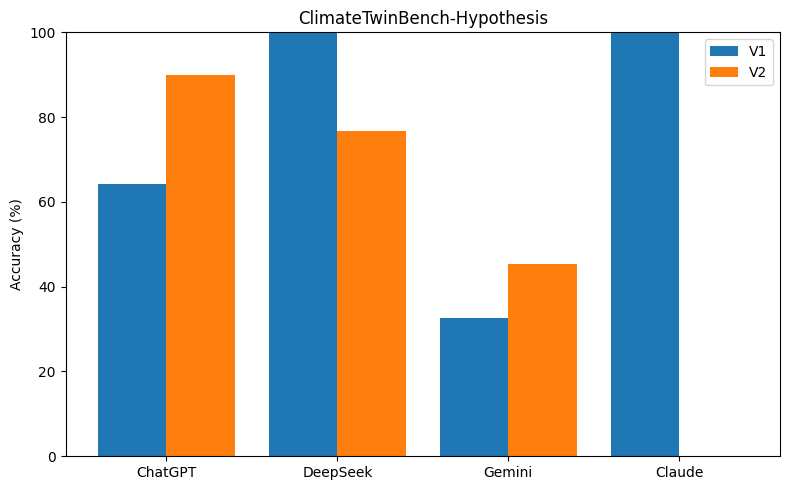

In [16]:
import matplotlib.pyplot as plt

plot_df = results.fillna(0)

x = range(len(plot_df))

plt.figure(figsize=(8,5))

plt.bar([i-0.2 for i in x], plot_df["V1"], width=0.4, label="V1")
plt.bar([i+0.2 for i in x], plot_df["V2"], width=0.4, label="V2")

plt.xticks(x, plot_df["Model"])
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
plt.title("ClimateTwinBench-Hypothesis")

plt.legend()

plt.tight_layout()

plt.show()

In [18]:
import json
from collections import Counter

benchmark = json.load(open("../benchmark/ClimateTwinBench_Hypothesis.json"))

questions = benchmark["questions"]

subcategory = Counter()
answers = Counter()

lengths=[]

for q in questions:

    subcategory[q["subcategory"]]+=1
    answers[q["answer"]]+=1
    lengths.append(len(q["question"].split()))

print("Questions:",len(questions))
print()

print("Answer Distribution")
print(answers)
print()

print("Subcategories")
print(subcategory)
print()

print("Average Prompt Length")
print(round(sum(lengths)/len(lengths),1))

Questions: 240

Answer Distribution
Counter({'B': 86, 'C': 79, 'A': 75})

Subcategories
Counter({'persistent_regional_anomaly_verification': 40, 'localized_intensification_verification': 40, 'wet_anomaly_consistency_verification': 40, 'compound_state_transition_verification': 40, 'spatial_coherence_verification': 40, 'reliability_aware_claim_verification': 40})

Average Prompt Length
161.0


In [19]:
hidden = [
    "min_yearly_mean_abs_anomaly",
    "min_fraction_cells_above_p75",
    "min_yearly_mean_completeness",
    "localized_contrast_change",
    "fraction_cells_rainfall_increased",
    "largest_component_size",
    "component_count",
    "active_cell_count"
]

bad=[]

for q in questions:

    text=str(q)

    for h in hidden:

        if h in text:
            bad.append((q["id"],h))

if len(bad)==0:
    print("✅ No hidden metrics leaked.")
else:
    print(bad)

[('HYP-001', 'min_yearly_mean_abs_anomaly'), ('HYP-001', 'min_fraction_cells_above_p75'), ('HYP-001', 'min_yearly_mean_completeness'), ('HYP-002', 'min_yearly_mean_abs_anomaly'), ('HYP-002', 'min_fraction_cells_above_p75'), ('HYP-002', 'min_yearly_mean_completeness'), ('HYP-003', 'min_yearly_mean_abs_anomaly'), ('HYP-003', 'min_fraction_cells_above_p75'), ('HYP-003', 'min_yearly_mean_completeness'), ('HYP-004', 'min_yearly_mean_abs_anomaly'), ('HYP-004', 'min_fraction_cells_above_p75'), ('HYP-004', 'min_yearly_mean_completeness'), ('HYP-005', 'min_yearly_mean_abs_anomaly'), ('HYP-005', 'min_fraction_cells_above_p75'), ('HYP-005', 'min_yearly_mean_completeness'), ('HYP-006', 'min_yearly_mean_abs_anomaly'), ('HYP-006', 'min_fraction_cells_above_p75'), ('HYP-006', 'min_yearly_mean_completeness'), ('HYP-007', 'min_yearly_mean_abs_anomaly'), ('HYP-007', 'min_fraction_cells_above_p75'), ('HYP-007', 'min_yearly_mean_completeness'), ('HYP-008', 'min_yearly_mean_abs_anomaly'), ('HYP-008', 'min_

In [20]:
gold = {q["id"]: q for q in questions}

pred = {}

with open("../evaluation/deepseek_hypothesis_v2.txt") as f:

    for line in f:

        if ":" not in line:
            continue

        k,v=line.strip().split(":")
        pred[k.strip()] = v.strip()

errors=[]

for qid in gold:

    if pred[qid] != gold[qid]["answer"]:

        errors.append(gold[qid])

print("Errors:",len(errors))

errors[:5]

Errors: 56


[{'id': 'HYP-025',
  'category': 'scientific_hypothesis_verification',
  'subcategory': 'persistent_regional_anomaly_verification',
  'difficulty': 'medium',
  'question': 'Hypothesis:\n  The 3x3 region centered at (24.00N, 81.00E) shows a persistent regional anomaly through 2022-2024.\n\nDecision protocol (all thresholds are derived from this dataset and printed below):\nFor each target year, three metrics are reported: regional mean |anomaly_score|, fraction of cells above the yearly P75 |anomaly_score| threshold, and mean completeness.\nIdentify the weakest year by finding the minimum value across all years for each metric.\nSUPPORTED if the minimum regional mean |anomaly_score| is at least the printed support_mean_abs_p75 threshold, the minimum fraction above P75 is at least support_fraction_above_p75, and the minimum mean completeness is at least support_completeness_p10.\nREFUTED if the minimum regional mean |anomaly_score| is at or below refute_mean_abs_p50, or the minimum fract

In [21]:
from collections import Counter

Counter([e["subcategory"] for e in errors])

Counter({'spatial_coherence_verification': 20,
         'compound_state_transition_verification': 10,
         'localized_intensification_verification': 8,
         'persistent_regional_anomaly_verification': 6,
         'wet_anomaly_consistency_verification': 6,
         'reliability_aware_claim_verification': 6})

In [22]:
results

,Model,V1,V2,Delta
0,ChatGPT,64.17,90.00,25.83
1,DeepSeek,100.00,76.67,-23.33
2,Gemini,32.50,45.42,12.92
3,Claude,100.00,NaN,NaN


In [23]:
import json

benchmark = json.load(open("../benchmark/ClimateTwinBench_Hypothesis.json"))

hidden = [
    "min_yearly_mean_abs_anomaly",
    "min_fraction_cells_above_p75",
    "min_yearly_mean_completeness",
    "localized_contrast_change",
    "fraction_cells_rainfall_increased",
    "largest_component_size",
    "component_count",
    "active_cell_count",
]

bad = []

for q in benchmark["questions"]:

    question = q["question"]

    for h in hidden:

        if h in question:
            bad.append((q["id"], h))

print("="*60)

if not bad:
    print("✅ PASS")
    print("No hidden metrics appear in the question text.")
else:
    print(f"❌ FAIL ({len(bad)} leaks)")
    for x in bad:
        print(x)

❌ FAIL (200 leaks)
('HYP-041', 'localized_contrast_change')
('HYP-042', 'localized_contrast_change')
('HYP-043', 'localized_contrast_change')
('HYP-044', 'localized_contrast_change')
('HYP-045', 'localized_contrast_change')
('HYP-046', 'localized_contrast_change')
('HYP-047', 'localized_contrast_change')
('HYP-048', 'localized_contrast_change')
('HYP-049', 'localized_contrast_change')
('HYP-050', 'localized_contrast_change')
('HYP-051', 'localized_contrast_change')
('HYP-052', 'localized_contrast_change')
('HYP-053', 'localized_contrast_change')
('HYP-054', 'localized_contrast_change')
('HYP-055', 'localized_contrast_change')
('HYP-056', 'localized_contrast_change')
('HYP-057', 'localized_contrast_change')
('HYP-058', 'localized_contrast_change')
('HYP-059', 'localized_contrast_change')
('HYP-060', 'localized_contrast_change')
('HYP-061', 'localized_contrast_change')
('HYP-062', 'localized_contrast_change')
('HYP-063', 'localized_contrast_change')
('HYP-064', 'localized_contrast_change

In [24]:
import json
from collections import Counter

benchmark = json.load(open("../benchmark/ClimateTwinBench_Hypothesis.json"))

hidden = [
    "min_yearly_mean_abs_anomaly",
    "min_fraction_cells_above_p75",
    "min_yearly_mean_completeness",
    "localized_contrast_change",
    "fraction_cells_rainfall_increased",
    "largest_component_size",
    "component_count",
    "active_cell_count",
]

counter = Counter()

for q in benchmark["questions"]:

    question = q["question"]

    for h in hidden:

        if h in question:
            counter[q["subcategory"]] += 1

print(counter)

if sum(counter.values()) == 0:
    print("\n✅ No evidence leakage detected in prompts.")
else:
    print("\n❌ Leakage still present.")

Counter({'spatial_coherence_verification': 120, 'localized_intensification_verification': 40, 'wet_anomaly_consistency_verification': 40})

❌ Leakage still present.


In [25]:
import json

bench = json.load(open("../benchmark/ClimateTwinBench_Hypothesis.json"))

for q in bench["questions"]:
    if q["subcategory"] == "localized_intensification_verification":
        print(q["question"])
        break

Hypothesis:
  The 3x3 region centered at (14.00N, 77.00E) locally intensified from 2024 to 2025: its anomaly increased more than its surrounding border and rainfall also increased.

Decision protocol (all thresholds are derived from this dataset and printed below):
Compute regional_abs_anomaly_change = mean_region(|A_later|) - mean_region(|A_earlier|). Compute border_abs_anomaly_change the same way on the surrounding border cells. Compute localized_contrast_change = regional_abs_anomaly_change - border_abs_anomaly_change. Compute regional_rainfall_change = mean_region(R_later - R_earlier).
SUPPORTED if regional_abs_anomaly_change is at least its candidate Q60 threshold, localized_contrast_change is at least its candidate Q75 threshold, and regional_rainfall_change is at least its candidate Q60 threshold.
REFUTED if any corresponding metric is at or below its candidate Q25 refutation threshold. INSUFFICIENT otherwise.

Thresholds:
  support_regional_change_q60: 0.0858
  refute_regional_

In [26]:
for q in bench["questions"]:
    if q["subcategory"] == "spatial_coherence_verification":
        print(q["question"])
        break

Hypothesis:
  In 2022, the 5x5 region centered at (24.25N, 81.50E) contains a spatially coherent anomaly rather than a fragmented active-cell pattern.

Decision protocol (all thresholds are derived from this dataset and printed below):
Mark a cell active if |anomaly_score| ≥ the yearly P80 threshold (active_cell_threshold_yearly_abs_p80 = 0.8192). Using 4-neighbor adjacency (up/down/left/right only), determine: active_cell_count (total active cells), largest_component_size (size of the largest connected cluster of active cells), component_count (number of distinct connected components), and largest_component_share = largest_component_size / active_cell_count.
The binary active-cell mask for the 5x5 region is provided in the evidence section (north-to-south rows; 1 = active, 0 = inactive).
SUPPORTED if active_cell_count and largest_component_size pass their printed minimum thresholds and component_count is at or below its printed maximum threshold. REFUTED if active_cell_count or larges

In [27]:
for q in bench["questions"]:
    if q["subcategory"] == "wet_anomaly_consistency_verification":
        print(q["question"])
        break

Hypothesis:
  For the 3x3 region centered at (24.25N, 84.25E), the 2020 positive anomaly signal is consistent with increased rainfall relative to 2019.

Decision protocol (all thresholds are derived from this dataset and printed below):
Compute the later-year regional mean signed anomaly_score, the regional rainfall change from earlier to later year, and fraction_cells_rainfall_increased = cells_with_rainfall_increase / total_region_cells.
SUPPORTED if later-year mean signed anomaly is at least the yearly P75 signed-anomaly threshold, rainfall change is at least its candidate Q75 threshold, and the fraction of rainfall-increase cells is at least its candidate Q75 threshold.
REFUTED if the signed anomaly is at or below the yearly P25 threshold, or if a high positive anomaly is paired with rainfall-change or rainfall-fraction evidence at or below its Q25 refutation threshold. INSUFFICIENT otherwise.

Thresholds:
  support_signed_anomaly_p75: 0.4835
  refute_signed_anomaly_p25: -0.2999
  

In [28]:
import json
from pprint import pprint

with open("../benchmark/ClimateTwinBench_Hypothesis_public.json", "r", encoding="utf-8") as f:
    bench = json.load(f)

targets = {
    "persistent_regional_anomaly_verification": ["medium", "hard"],
    "localized_intensification_verification": ["medium", "hard"],
    "wet_anomaly_consistency_verification": ["medium", "hard"],
    "compound_state_transition_verification": ["medium", "hard"],
    "spatial_coherence_verification": ["medium", "hard"],
    "reliability_aware_claim_verification": ["medium", "hard"],
}

selected = []

for subcat, diffs in targets.items():
    for diff in diffs:
        for q in bench["questions"]:
            if q["subcategory"] == subcat and q["difficulty"] == diff:
                selected.append(q)
                break

print(f"Selected {len(selected)} questions\n")

for q in selected:
    print("="*100)
    print(q["id"], "|", q["subcategory"], "|", q["difficulty"])
    print()
    print(q["question"])
    print()
    for k,v in q["options"].items():
        print(f"{k}. {v}")
    print()

Selected 10 questions

HYP-001 | persistent_regional_anomaly_verification | medium

Hypothesis:
  The 3x3 region centered at (18.75N, 83.75E) shows a persistent regional anomaly through 2021-2023.

Decision protocol (all thresholds are derived from this dataset and printed below):
For each target year, three metrics are reported: regional mean |anomaly_score|, fraction of cells above the yearly P75 |anomaly_score| threshold, and mean completeness.
Identify the weakest year by finding the minimum value across all years for each metric.
SUPPORTED if the minimum regional mean |anomaly_score| is at least the printed support_mean_abs_p75 threshold, the minimum fraction above P75 is at least support_fraction_above_p75, and the minimum mean completeness is at least support_completeness_p10.
REFUTED if the minimum regional mean |anomaly_score| is at or below refute_mean_abs_p50, or the minimum fraction above P75 is at or below refute_fraction_above_p75, or any yearly mean completeness falls be

In [29]:
from collections import Counter
import re

evaluate("../evaluation/deepseek_hypothesis_v2.txt")

print("\nPer-subcategory\n")

correct = Counter()
total = Counter()

for q in benchmark["questions"]:
    total[q["subcategory"]] += 1
    if answers[q["id"]] == q["answer"]:
        correct[q["subcategory"]] += 1

for k in total:
    print(f"{k:45} {correct[k]:2}/{total[k]} ({100*correct[k]/total[k]:.2f}%)")

print("\nDifficulty\n")

correct = Counter()
total = Counter()

for q in benchmark["questions"]:
    total[q["difficulty"]] += 1
    if answers[q["id"]] == q["answer"]:
        correct[q["difficulty"]] += 1

for k in total:
    print(f"{k:10} {correct[k]:3}/{total[k]} ({100*correct[k]/total[k]:.1f}%)")

print("\nMistake Breakdown")

mistakes = Counter()

for q in benchmark["questions"]:
    if answers[q["id"]] != q["answer"]:
        mistakes[q["subcategory"]] += 1

print("Mistakes:", sum(mistakes.values()))
print(mistakes)

Correct: 237/240
Accuracy: 98.75%

Per-subcategory

persistent_regional_anomaly_verification       0/40 (0.00%)
localized_intensification_verification         0/40 (0.00%)
wet_anomaly_consistency_verification           0/40 (0.00%)
compound_state_transition_verification         0/40 (0.00%)
spatial_coherence_verification                 0/40 (0.00%)
reliability_aware_claim_verification           0/40 (0.00%)

Difficulty

medium       0/104 (0.0%)
hard         0/136 (0.0%)

Mistake Breakdown
Mistakes: 240
Counter({'persistent_regional_anomaly_verification': 40, 'localized_intensification_verification': 40, 'wet_anomaly_consistency_verification': 40, 'compound_state_transition_verification': 40, 'spatial_coherence_verification': 40, 'reliability_aware_claim_verification': 40})


In [30]:
import json
import re

with open("../benchmark/ClimateTwinBench_Hypothesis_public.json","r",encoding="utf-8") as f:
    benchmark=json.load(f)

answers={}

with open("../evaluation/deepseek_hypothesis_v2.txt","r",encoding="utf-8") as f:
    for line in f:
        m=re.match(r"(HYP-\d+):\s*([ABC])",line.strip())
        if m:
            answers[m.group(1)]=m.group(2)

print(len(answers))

240


In [32]:
benchmark["questions"][0]

{'id': 'HYP-001',
 'category': 'scientific_hypothesis_verification',
 'subcategory': 'persistent_regional_anomaly_verification',
 'difficulty': 'medium',
 'question': 'Hypothesis:\n  The 3x3 region centered at (18.75N, 83.75E) shows a persistent regional anomaly through 2021-2023.\n\nDecision protocol (all thresholds are derived from this dataset and printed below):\nFor each target year, three metrics are reported: regional mean |anomaly_score|, fraction of cells above the yearly P75 |anomaly_score| threshold, and mean completeness.\nIdentify the weakest year by finding the minimum value across all years for each metric.\nSUPPORTED if the minimum regional mean |anomaly_score| is at least the printed support_mean_abs_p75 threshold, the minimum fraction above P75 is at least support_fraction_above_p75, and the minimum mean completeness is at least support_completeness_p10.\nREFUTED if the minimum regional mean |anomaly_score| is at or below refute_mean_abs_p50, or the minimum fraction a

In [33]:
import json

with open("../benchmark/ClimateTwinBench_Hypothesis.json","r",encoding="utf-8") as f:
    bench=json.load(f)

print(bench["questions"][0].keys())

dict_keys(['id', 'category', 'subcategory', 'difficulty', 'question', 'options', 'answer', 'explanation', 'context'])


In [34]:
import json
import re
from collections import Counter

# Load PRIVATE benchmark (contains answers)
with open("../benchmark/ClimateTwinBench_Hypothesis.json","r",encoding="utf-8") as f:
    benchmark=json.load(f)

# Load DeepSeek predictions
answers={}

with open("../evaluation/deepseek_hypothesis_v2.txt","r",encoding="utf-8") as f:
    for line in f:
        m=re.match(r"(HYP-\d+):\s*([ABC])",line.strip())
        if m:
            answers[m.group(1)] = m.group(2)

correct=0

correct_sub=Counter()
total_sub=Counter()

correct_diff=Counter()
total_diff=Counter()

mistakes=Counter()

for q in benchmark["questions"]:

    gt=q["answer"]
    pred=answers.get(q["id"],None)

    total_sub[q["subcategory"]]+=1
    total_diff[q["difficulty"]]+=1

    if pred==gt:
        correct+=1
        correct_sub[q["subcategory"]]+=1
        correct_diff[q["difficulty"]]+=1
    else:
        mistakes[q["subcategory"]]+=1

print("="*80)
print(f"Correct: {correct}/{len(benchmark['questions'])}")
print(f"Accuracy: {100*correct/len(benchmark['questions']):.2f}%")

print("\nPer-subcategory\n")

for s in total_sub:
    print(f"{s:45} {correct_sub[s]:2}/{total_sub[s]} ({100*correct_sub[s]/total_sub[s]:.2f}%)")

print("\nDifficulty\n")

for d in total_diff:
    print(f"{d:10} {correct_diff[d]:3}/{total_diff[d]} ({100*correct_diff[d]/total_diff[d]:.1f}%)")

print("\nMistake Breakdown")
print("Mistakes:",sum(mistakes.values()))
print(mistakes)

Correct: 237/240
Accuracy: 98.75%

Per-subcategory

persistent_regional_anomaly_verification      40/40 (100.00%)
localized_intensification_verification        39/40 (97.50%)
wet_anomaly_consistency_verification          40/40 (100.00%)
compound_state_transition_verification        40/40 (100.00%)
spatial_coherence_verification                40/40 (100.00%)
reliability_aware_claim_verification          38/40 (95.00%)

Difficulty

medium     103/104 (99.0%)
hard       134/136 (98.5%)

Mistake Breakdown
Mistakes: 3
Counter({'reliability_aware_claim_verification': 2, 'localized_intensification_verification': 1})


In [35]:
for q in benchmark["questions"]:
    if answers[q["id"]] != q["answer"]:
        print("="*100)
        print(q["id"])
        print(q["subcategory"])
        print("GT :", q["answer"])
        print("Pred:", answers[q["id"]])
        print()
        print(q["question"])

HYP-062
localized_intensification_verification
GT : B
Pred: C

Hypothesis:
  The 3x3 region centered at (28.50N, 76.75E) locally intensified from 2022 to 2023: its anomaly increased more than its surrounding border and rainfall also increased.

Decision protocol (all thresholds are derived from this dataset and printed below):
Compute regional_abs_anomaly_change = mean_region(|A_later|) - mean_region(|A_earlier|). Compute border_abs_anomaly_change the same way on the surrounding border cells. Compute localized_contrast_change = regional_abs_anomaly_change - border_abs_anomaly_change. Compute regional_rainfall_change = mean_region(R_later - R_earlier).
SUPPORTED if regional_abs_anomaly_change is at least its candidate Q60 threshold, localized_contrast_change is at least its candidate Q75 threshold, and regional_rainfall_change is at least its candidate Q60 threshold.
REFUTED if any corresponding metric is at or below its candidate Q25 refutation threshold. INSUFFICIENT otherwise.

Thres

In [36]:
for q in benchmark["questions"]:
    if q["id"]=="HYP-229":
        print(q["options"])
        print(q["answer"])

{'A': 'REFUTED - regional anomaly magnitude is at or below the refutation threshold', 'B': 'INSUFFICIENT - the anomaly magnitude is not strong enough for support but not low enough for refutation', 'C': 'SUPPORTED - both anomaly magnitude and completeness pass their support thresholds'}
B
